In [2]:
import pandas as pd

dataset = pd.read_csv("/kaggle/input/food-com-recipes-and-user-interactions/PP_recipes.csv")

**以下是HW1的第一題的第1小題**

**1(a)**

In [59]:
import re
from collections import defaultdict, Counter
import random
import math


def preprocess(text, regex=re.compile(r'[^a-z\s]')):

    text = text.lower()    
    text = regex.sub('', text)
    tokens = text.split()
    return ["<s>"] + tokens + ["</s>"]
    
# 把文字轉成token(變小寫 刪掉空白和其他符號 切割空白變成詞)

def read_file(path, max_lines=50000):

    data = []
    line_count = 0
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            if line.strip():
                data.append(preprocess(line.strip()))
                line_count += 1
            if max_lines and line_count >= max_lines:
                break
    print(f" Loaded {line_count} lines from {path}")
    return data

# 逐行讀取避免檔案太大 把每行處理的結果加進data裡

train_data = read_file('/kaggle/input/hw1-1-data/train.txt', max_lines=30000)
test_data = read_file('/kaggle/input/hw1-1-data/test.txt', max_lines=10000)
incomplete_data = read_file('/kaggle/input/hw1-1-data/incomplete.txt', max_lines=500)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))
print("Incomplete samples:", len(incomplete_data))

# 分別建立訓練 測試 不完整 的資料集


 Loaded 30000 lines from /kaggle/input/hw1-1-data/train.txt
 Loaded 10000 lines from /kaggle/input/hw1-1-data/test.txt
 Loaded 10 lines from /kaggle/input/hw1-1-data/incomplete.txt
Train samples: 30000
Test samples: 10000
Incomplete samples: 10


In [60]:
from collections import defaultdict

def build_ngram(tokens_list, n=2):
    ngram_counts = defaultdict(int)
    context_counts = defaultdict(int)
    vocab = set()

# 紀錄N-gram和N-gram前n-1個詞的出現次數 還有儲存所有出現過的詞彙
    
    for tokens in tokens_list:
        for i in range(len(tokens) - n + 1):
            ngram = tuple(tokens[i:i+n])
            context = tuple(tokens[i:i+n-1])
            ngram_counts[ngram] += 1
            context_counts[context] += 1
            vocab.update(ngram)

    return ngram_counts, context_counts, vocab

bigram_counts, bigram_contexts, vocab = build_ngram(train_data, n=2)
trigram_counts, trigram_contexts, vocab = build_ngram(train_data, n=3)

# 建立Bigram和Trigram的模型

print("Bigram samples:", len(bigram_counts))
print("Trigram samples:", len(trigram_counts))


Bigram samples: 45108
Trigram samples: 97106


In [61]:
import random
from collections import defaultdict

def build_context_index(ngram_counts):
    context_index = defaultdict(list)
    for ngram, count in ngram_counts.items():
        context = ngram[:-1]
        context_index[context].append((ngram[-1], count))
    return context_index

# 建立查表來加速預測

print(" Building context indexes (this step only runs once)")
bigram_index = build_context_index(bigram_counts)
trigram_index = build_context_index(trigram_counts)
print(f" Bigram index size: {len(bigram_index)}")
print(f" Trigram index size: {len(trigram_index)}")


def predict_next_word_fast(context, context_index, vocab):
    if context not in context_index:
        return random.choice(list(vocab))
    return max(context_index[context], key=lambda x: x[1])[0]

# 用來預測下一個詞為何

def evaluate_fast(test_sentences, context_index, vocab, n=2, limit=200):
    correct = 0
    total = 0
    sampled = random.sample(test_sentences, min(limit, len(test_sentences)))

    for idx, tokens in enumerate(sampled):
        for i in range(n - 1, len(tokens) - 1):
            context = tuple(tokens[i - n + 1:i])
            true_next = tokens[i]
            pred_next = predict_next_word_fast(context, context_index, vocab)
            if pred_next == true_next:
                correct += 1
            total += 1
        if (idx + 1) % 50 == 0:
            print(f" processed {idx+1}/{limit} sentences")

    return correct / total if total > 0 else 0

# 測試模型的準確率 每個位置都會比較模型預測值與真實答案是否一致

print("\n Evaluating on sampled test set (200 sentences, indexed mode)")

bigram_acc = evaluate_fast(test_data, bigram_index, vocab, n=2, limit=200)
trigram_acc = evaluate_fast(test_data, trigram_index, vocab, n=3, limit=200)

print(f"\n Bigram accuracy (sampled 200): {bigram_acc*100:.2f}%")
print(f" Trigram accuracy (sampled 200): {trigram_acc*100:.2f}%")

# 執行與評估結果

 Building context indexes (this step only runs once)
 Bigram index size: 5363
 Trigram index size: 42768

 Evaluating on sampled test set (200 sentences, indexed mode)
 processed 50/200 sentences
 processed 100/200 sentences
 processed 150/200 sentences
 processed 200/200 sentences
 processed 50/200 sentences
 processed 100/200 sentences
 processed 150/200 sentences
 processed 200/200 sentences

 Bigram accuracy (sampled 200): 16.64%
 Trigram accuracy (sampled 200): 25.90%


Bigram accuracy的準確度只有16.64%
Trigram accuracy的準確度有25.90%

雖然Trigram accuracy的準確度比較高，因為它比Bigram accuracy多看了前一個字，但準確度依舊不夠好，原因是模型不夠smooth也沒有考慮到機率的隨機性，因此準確度才沒有重大性的進步

**1(b)**

基本上N-Gram都是使用CPU來進行的，其中又可以發現在執行Trigram 的時候比執行 Bigram 的時候記憶體容量有明顯上升，執行所需要的時間也是Trigram需要比較長的時間。
另外，GPU的使用率幾乎是0%是因為這還不是深度學習的模型，還暫時用不到GPU。


**1(c)**

In [62]:
def generate_sentence(seed_tokens, context_index, vocab, n=3, max_len=20):
    tokens = seed_tokens[:]
    while len(tokens) < max_len:
        context = tuple(tokens[-(n-1):])
        next_word = predict_next_word_fast(context, context_index, vocab)
        tokens.append(next_word)
        if next_word == "</s>":
            break

    return " ".join([t for t in tokens if t not in ("<s>", "</s>")])

# 利用N-gram模型一個字一個字去生成完整的句子，並不讓句子超過20字

print("\n Generated sentences (Trigram model):")
for i, inc in enumerate(incomplete_data[:10]):
    sentence = generate_sentence(inc, trigram_index, vocab, n=3)
    print(f"[{i+1}] {sentence}")




 Generated sentences (Trigram model):
[1] cover with disappears crepes including aromatics dampened potatoe between lowheat cukes catch colada unable fairly brats last saltimbocca
[2] roll up refridgerate disguise prebaked bwl oz cassoulet kosher shortcrust preparation wanted tsp holly replace paperlined lemonlime repeat
[3] cook the scrapper forth skinless list oyster crisply basket love sprinkling parallel loosen mildly threequarters goods slather oreo
[4] stir in lambartichoke thank lbs immediately scone gingerroot veg lifting boiled depression eight prettiest peeled occsionally immersion pickling
[5] spread out tomatoandchipotle porkchops smoker roomy cornflakes evaporated poor slightly sorry gum reasonable most kick cacao roux tuck
[6] transfer the sweetandsour opinion hamburger completely wear stuckon stevia squeak make pink plates tortellini ras same tbspn untilmelted
[7] put the prawns claws garlicbuttered frm between eggsweet dilute pea croissants mailbou racks rolling olives

上面十行就是把不完整句子完整的結果

**以下是HW1的第一題的第2小題**

**2(a)**

Loaded 30001 lines from /kaggle/input/hw1-1-data/train.txt
Loaded 5001 lines from /kaggle/input/hw1-1-data/test.txt
Vocabulary size: 6213
Epoch [1/10] - Loss: 4.5963, Acc: 24.62%
Epoch [2/10] - Loss: 3.8347, Acc: 30.36%
Epoch [3/10] - Loss: 3.5704, Acc: 32.18%
Epoch [4/10] - Loss: 3.3980, Acc: 33.49%
Epoch [5/10] - Loss: 3.2676, Acc: 34.63%
Epoch [6/10] - Loss: 3.1656, Acc: 35.65%
Epoch [7/10] - Loss: 3.0783, Acc: 36.68%
Epoch [8/10] - Loss: 3.0065, Acc: 37.56%
Epoch [9/10] - Loss: 2.9433, Acc: 38.43%
Epoch [10/10] - Loss: 2.8881, Acc: 39.23%


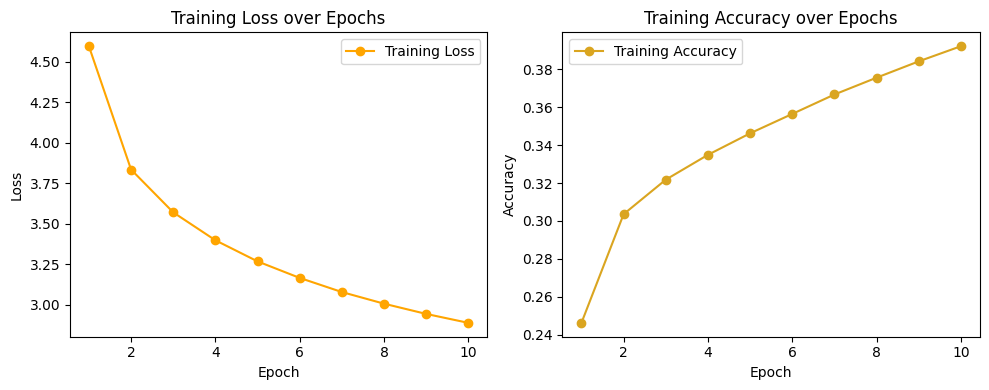

In [63]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import numpy as np
import math

def preprocess(text):
    text = text.lower()
    tokens = text.split()
    return ["<s>"] + tokens + ["</s>"]

# 把文字切成TOKEN 加上句首句尾

def read_file(path, max_lines=None):
    data = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip():
                data.append(preprocess(line.strip()))
            if max_lines and i >= max_lines:
                break
    print(f"Loaded {len(data)} lines from {path}")
    return data

# 逐行讀檔 存入data

train_data = read_file('/kaggle/input/hw1-1-data/train.txt', max_lines=30000)
test_data  = read_file('/kaggle/input/hw1-1-data/test.txt', max_lines=5000)

# 讀入訓練與測試的資料 回傳到token list

special_tokens = ["<pad>", "<unk>", "<s>", "</s>"]
all_tokens = [token for line in train_data for token in line]
vocab = sorted(set(all_tokens))
vocab = special_tokens + [v for v in vocab if v not in special_tokens]

# 把訓練集中出現過的詞做成詞彙表 再把特別的token放在最前面

word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for word, i in word2idx.items()}
pad_id = word2idx["<pad>"]
unk_id = word2idx["<unk>"]
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

# 建立詞與索引的雙向字典對照

encoded_train = [[word2idx.get(w, unk_id) for w in line] for line in train_data]
encoded_test  = [[word2idx.get(w, unk_id) for w in line] for line in test_data]

# 把每個token轉乘int 沒在字典裡的用unk_id代替

class LMDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx][:-1])
        y = torch.tensor(self.data[idx][1:])
        return x, y

def collate_fn(batch):
    xs, ys = zip(*batch)
    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = pad_sequence(ys, batch_first=True, padding_value=pad_id)
    return xs, ys

# 分成一個語言模型的資料集 資料不同長度的自動padding到等長

train_loader = DataLoader(
    LMDataset(encoded_train),
    batch_size=32, shuffle=True, drop_last=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    LMDataset(encoded_test),
    batch_size=32, shuffle=False, drop_last=False,
    collate_fn=collate_fn
)

# 建立訓練和測試的資料集

class RNNLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, pad_idx=0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn   = nn.RNN(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc    = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.rnn(x, hidden)
        out = self.fc(out)
        return out, hidden

# 建立RNN模型

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RNNLanguageModel(vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, pad_idx=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

num_epochs = 10
train_losses, train_accuracies = [], []

# 訓練設定參數

for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = criterion(out.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

# 訓練迴圈

        total_loss += loss.item()
        preds = out.argmax(dim=2)
        mask = (y != pad_id)
        correct += ((preds == y) & mask).sum().item()
        total += mask.sum().item()

# 計算以token為單位的accuracy

    avg_loss = total_loss / len(train_loader)
    acc = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Acc: {acc*100:.2f}%")

# 每個 epoch 的訓練平均 loss/accuracy

epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o', color='orange', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker='o', color='goldenrod', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

由上面的結果可知道，模型在10個epochs內，loss從4.59降到2.88，accurary從24.62%升到39.23%

**2(b)**

In [64]:
criterion_sum = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
model.eval()
loss_sum, correct, count_tokens = 0.0, 0, 0

# 變數初始化

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out, _ = model(x)
        loss_sum += criterion_sum(out.view(-1, vocab_size), y.view(-1)).item()
        mask = (y != pad_id)
        preds = out.argmax(dim=2)
        correct += ((preds == y) & mask).sum().item()
        count_tokens += mask.sum().item()

# 計算test loss和test accuracy

avg_nll_ln   = loss_sum / count_tokens
avg_nll_log2 = avg_nll_ln / math.log(2)
ppl          = 2 ** avg_nll_log2
test_acc     = correct / count_tokens

print(f"Average Test Loss             : {avg_nll_log2:.4f}")
print(f"Test Accuracy                 : {test_acc*100:.2f}%")
print(f"Perplexity (PPL)              : {ppl:.2f}")

Average Test Loss             : 5.9098
Test Accuracy                 : 31.31%
Perplexity (PPL)              : 60.12


上面的結果代表模型在test訓練集上預測下一個單字的準確率是31.31% perplexity是60.12代表模型在猜下一個字時有60.12個選擇

**2(c)**

In [65]:
def generate_sentence_20(model, seed_tokens, target_words=20):

    model.eval()
    tokens = [t for t in seed_tokens if t != "</s>"]
    hidden = None

# 把句尾</s>一掉 避免一開始就視為結束
    
    def count_real(ts):
        return sum(t not in ("<s>", "</s>", "<pad>") for t in ts)

# 計算序列中的非特殊詞

    with torch.no_grad():
        max_steps = max(60, target_words * 4)

        for _ in range(max_steps):
            if count_real(tokens) >= target_words:
                break

# 主迴圈 如果已達到目鰾字數20就停止
                
            x = torch.tensor([[word2idx.get(w, unk_id) for w in tokens]], dtype=torch.long, device=device)
            out, hidden = model(x, hidden)
            logits = out[0, -1, :].clone()

# 把token映射成索引序列丟進去

            if "<s>" in word2idx:
                logits[word2idx["<s>"]] = -1e9
            if "<pad>" in word2idx:
                logits[word2idx["<pad>"]] = -1e9
            if count_real(tokens) < target_words and "</s>" in word2idx:
                logits[word2idx["</s>"]] = -1e9

# 一樣在達標前不能停止

            next_id = int(torch.argmax(logits).item())
            next_word = idx2word[next_id]
            tokens.append(next_word)

        if tokens[-1] != "</s>":
            tokens.append("</s>")

# 選擇下一個最大機率的詞生成 並補上句尾標記

    return " ".join([t for t in tokens if t not in ("<s>", "</s>", "<pad>")])

for i, sent in enumerate(read_file('/kaggle/input/hw1-1-data/incomplete.txt')[:10]):
    completed = generate_sentence_20(model, sent, target_words=20)
    length = sum(w not in ("<s>", "</s>", "<pad>") for w in completed.split())
    print(f"[{i+1}] {completed}")

Loaded 10 lines from /kaggle/input/hw1-1-data/incomplete.txt
[1] cover with foil and bake at 350 degrees for 30 minutes or until the chicken is cooked through and the
[2] roll up the mixture into the prepared pan and bake for 20 minutes or until the chicken is cooked through
[3] cook the unpeeled 1 minute longer or until the chicken is golden brown and the cheese is melted and ligthly
[4] stir in the butter and mix well and returning to a few minutes before serving and serve with the steamed
[5] spread out evenly over the top of the meat and let it sit for a few minutes before serving and
[6] transfer the mixture to a bowl and cover with a lid and pulse until golden brown and opaque on the
[7] put the pork in a shallow baking pan and bake for 20 minutes or until the chicken is cooked through
[8] push the envelope from the pan and the edges of the slices: it is to use a fork to get
[9] cut into squares and serve with the steamed asparagus and cook for another minute or until golden brow

以上10句就是把不完整句子完整的結果，並且加到至20字

**以下是HW1的第一題的第3小題**

**3(a)**

Loaded 30001 lines from /kaggle/input/hw1-1-data/train.txt
Loaded 5001 lines from /kaggle/input/hw1-1-data/test.txt
Vocabulary size: 6213
Epoch [1/10] - Loss: 5.3792, Acc: 17.11%
Epoch [2/10] - Loss: 4.5007, Acc: 24.40%
Epoch [3/10] - Loss: 4.0774, Acc: 28.63%
Epoch [4/10] - Loss: 3.8397, Acc: 30.79%
Epoch [5/10] - Loss: 3.6732, Acc: 32.24%
Epoch [6/10] - Loss: 3.5431, Acc: 33.43%
Epoch [7/10] - Loss: 3.4325, Acc: 34.33%
Epoch [8/10] - Loss: 3.3367, Acc: 35.25%
Epoch [9/10] - Loss: 3.2494, Acc: 36.07%
Epoch [10/10] - Loss: 3.1722, Acc: 36.87%


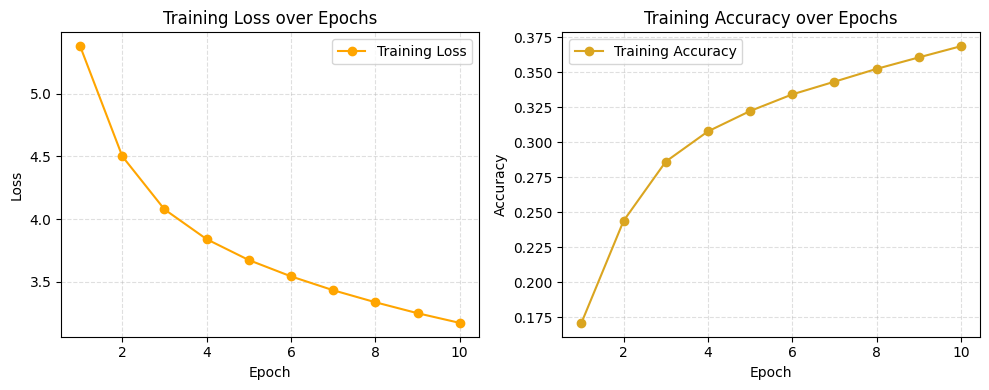

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import numpy as np
import math

def preprocess(text):
    text = text.lower()
    tokens = text.split()
    return ["<s>"] + tokens + ["</s>"]

# 把文字切成TOKEN 加上句首句尾

def read_file(path, max_lines=None):
    data = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip():
                data.append(preprocess(line.strip()))
            if max_lines and i >= max_lines:
                break
    print(f"Loaded {len(data)} lines from {path}")
    return data

# 逐行讀檔 存入data

train_data = read_file('/kaggle/input/hw1-1-data/train.txt', max_lines=30000)
test_data  = read_file('/kaggle/input/hw1-1-data/test.txt', max_lines=5000)

# 讀入訓練與測試的資料 回傳到token list

special_tokens = ["<pad>", "<unk>", "<s>", "</s>"]
all_tokens = [token for line in train_data for token in line]
vocab = sorted(set(all_tokens))
vocab = special_tokens + [v for v in vocab if v not in special_tokens]

# 把訓練集中出現過的詞做成詞彙表 再把特別的token放在最前面

word2idx = {word: i for i, word in enumerate(vocab)}
idx2word = {i: word for word, i in word2idx.items()}
pad_id = word2idx["<pad>"]
unk_id = word2idx["<unk>"]
vocab_size = len(word2idx)
print("Vocabulary size:", vocab_size)

# 建立詞與索引的雙向字典對照

encoded_train = [[word2idx.get(w, unk_id) for w in line] for line in train_data]
encoded_test  = [[word2idx.get(w, unk_id) for w in line] for line in test_data]

# 把每個token轉乘int 沒在字典裡的用unk_id代替

class LMDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        x = torch.tensor(self.data[idx][:-1])
        y = torch.tensor(self.data[idx][1:])
        return x, y

def collate_fn(batch):
    xs, ys = zip(*batch)
    xs = pad_sequence(xs, batch_first=True, padding_value=pad_id)
    ys = pad_sequence(ys, batch_first=True, padding_value=pad_id)
    return xs, ys

# 分成一個語言模型的資料集 資料不同長度的自動padding到等長

train_loader = DataLoader(
    LMDataset(encoded_train),
    batch_size=32, shuffle=True, drop_last=True,
    collate_fn=collate_fn
)
test_loader = DataLoader(
    LMDataset(encoded_test),
    batch_size=32, shuffle=False, drop_last=False,
    collate_fn=collate_fn
)

# 建立訓練和測試的資料集

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, pad_idx=0):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc    = nn.Linear(hidden_dim, vocab_size)
    def forward(self, x, hidden=None):
        x = self.embed(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out)
        return out, hidden

# 建立LTSM模型

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LSTMLanguageModel(vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, pad_idx=pad_id).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=pad_id)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses, train_accuracies = [], []

# 訓練設定參數

for epoch in range(num_epochs):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out, _ = model(x)
        loss = criterion(out.view(-1, vocab_size), y.view(-1))
        loss.backward()
        optimizer.step()

# 訓練迴圈

        total_loss += loss.item()
        preds = out.argmax(dim=2)
        mask = (y != pad_id)
        correct += ((preds == y) & mask).sum().item()
        total += mask.sum().item()

# 計算以token為單位的accuracy

    avg_loss = total_loss / len(train_loader)
    acc = correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f}, Acc: {acc*100:.2f}%")

# 每個 epoch 的訓練平均 loss/accuracy

epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o', color='orange', label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker='o', color='goldenrod', label='Training Accuracy')
plt.title('Training Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

由上面的結果可知道，模型在10個epochs內，loss從5.37降到3.17，accurary從17.11%升到36.87%

**3(b)**

In [8]:
criterion_sum = nn.CrossEntropyLoss(ignore_index=pad_id, reduction='sum')
model.eval()
loss_sum, correct, count_tokens = 0.0, 0, 0

# 變數初始化

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out, _ = model(x)
        loss_sum += criterion_sum(out.view(-1, vocab_size), y.view(-1)).item()
        mask = (y != pad_id)
        preds = out.argmax(dim=2)
        correct += ((preds == y) & mask).sum().item()
        count_tokens += mask.sum().item()

# 計算test loss和test accuracy

avg_nll_ln   = loss_sum / count_tokens
avg_nll_log2 = avg_nll_ln / math.log(2)
ppl          = 2 ** avg_nll_log2
test_acc     = correct / count_tokens

print(f"Average Test Loss (log2 base) : {avg_nll_log2:.4f}")
print(f"Test Accuracy                 : {test_acc*100:.2f}%")
print(f"Perplexity (PPL)              : {ppl:.2f}")

Average Test Loss (log2 base) : 5.6151
Test Accuracy                 : 32.38%
Perplexity (PPL)              : 49.01


上面的結果代表模型在test訓練集上預測下一個單字的準確率是32.38%
perplexity是49.01代表模型在猜下一個字時有49個選擇

**3(c)**

In [9]:
def generate_sentence_20(model, seed_tokens, target_words=20):

    model.eval()
    tokens = [t for t in seed_tokens if t != "</s>"]
    hidden = None

# 把句尾</s>一掉 避免一開始就視為結束
    
    def count_real(ts):
        return sum(t not in ("<s>", "</s>", "<pad>") for t in ts)

# 計算序列中的非特殊詞

    with torch.no_grad():
        max_steps = max(60, target_words * 4)

        for _ in range(max_steps):
            if count_real(tokens) >= target_words:
                break

# 主迴圈 如果已達到目鰾字數20就停止
                
            x = torch.tensor([[word2idx.get(w, unk_id) for w in tokens]], dtype=torch.long, device=device)
            out, hidden = model(x, hidden)
            logits = out[0, -1, :].clone()

# 把token映射成索引序列丟進去

            if "<s>" in word2idx:
                logits[word2idx["<s>"]] = -1e9
            if "<pad>" in word2idx:
                logits[word2idx["<pad>"]] = -1e9
            if count_real(tokens) < target_words and "</s>" in word2idx:
                logits[word2idx["</s>"]] = -1e9

# 一樣在達標前不能停止

            next_id = int(torch.argmax(logits).item())
            next_word = idx2word[next_id]
            tokens.append(next_word)

        if tokens[-1] != "</s>":
            tokens.append("</s>")

# 選擇下一個最大機率的詞生成 並補上句尾標記

    return " ".join([t for t in tokens if t not in ("<s>", "</s>", "<pad>")])

for i, sent in enumerate(read_file('/kaggle/input/hw1-1-data/incomplete.txt')[:10]):
    completed = generate_sentence_20(model, sent, target_words=20)
    length = sum(w not in ("<s>", "</s>", "<pad>") for w in completed.split())
    print(f"[{i+1}] {completed}")

Loaded 10 lines from /kaggle/input/hw1-1-data/incomplete.txt
[1] cover with plastic wrap and refrigerate for at least 2 hours or overnight in the refrigerator for about 2 hours
[2] roll up the dough to a rack to cool completely before serving and place on a baking sheet and bake
[3] cook the pasta in a large pot over medium heat until the mixture is smooth and creamy and the mixture
[4] stir in the remaining ingredients and mix well to coat well with a wire whisk until well blended and set
[5] spread out the mixture over the top of the top and place them in the refrigerator for about 2 hours
[6] transfer the chicken to a large bowl and pour the sauce over the top of the top of the pan
[7] put the pan in the oven and bake for about 20 minutes or until the chicken is tender and the
[8] push the dough into a ball and place them in the oven for about 1 hour or until the mixture
[9] cut into 1 / 2-inch slices and place on a cookie sheet with a fork or spoon to the dough
[10] toss the chicke

以上10句就是把不完整句子完整的結果，並且加到至20字

**以下是HW1的第一題的第4小題**

**4**


n-gram模型是利用前n–1個詞的機率關係預測下一詞，無法預測長期關係。 RNN模型是透過遞迴結構將隱藏狀態捕捉，可以捕捉長距離的關係，但容易梯度消失或爆炸。LSTM模型則是在RNN模型的基礎下加入了gate的機制，能有效保存長期資訊，進而減少梯度產生的問題。



硬體資源的需求 :  n-gram模型運算需求少但需要大量的儲存空間。RNN模型計算量比n-gram模型多，而且也需要一些空間保存梯度。LSTM模型需要gate運算的參數，參數數量多，需要的計算時間也最久。

訓練時間的比較: n-gram模型只需要計算詞的數量及機率，所需的時間最快，RNN模型因為時間步的關係強，所以訓練時間中等。LSTM模型因為有gate的關係，需要運算更多矩陣乘法，因此需要最久的訓練時間。

實驗結果比較: n-gram模型的準確率最低，因為它只依賴短期上下文之間的關係。RNN模型它可以捕捉序列結構，比n-gram模型表現更好，馾還是有梯度的問題。LSTM模型因為有gate機制，長期的結構捕捉得更好，因此準確率最高。